## Final Plots for SIAM Paper Submission

### IMPORTS

In [1]:
import torch
import numpy as np
import GPKoopman as gpk
from datetime import datetime
import matplotlib.pyplot as plt
import math
from get_iGPK_new import get_iGPK
import os
from datetime import datetime

In [2]:
def _nlpd_one(y, mu, S, jitter=1e-8):
    """
    NLPD for a single multivariate Gaussian y~N(mu,S).
    y, mu: (n,)
    S: (n,n) covariance
    Returns scalar (float)
    """
    n = y.numel()
    S = 0.5 * (S + S.T)  # symmetrize
    S = S + jitter * torch.eye(n, dtype=S.dtype)
    try:
        L = torch.linalg.cholesky(S)
        logdet = 2.0 * torch.log(torch.diag(L)).sum()
        diff = (y - mu).view(n, 1)
        sol = torch.cholesky_solve(diff, L)
        quad = float((diff.T @ sol).item())
        return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)
    except Exception:
        # Diagonal fallback
        diag = torch.clamp(torch.diagonal(S), min=jitter)
        logdet = torch.log(diag).sum()
        quad = ((y - mu) ** 2 / diag).sum().item()
        return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)

def _nlpd_per_traj(Xhat, Xcv, GT):
    """
    Average NLPD per trajectory across time-steps.
    returns (nTraj,) tensor
    """
    nTraj, n, N = Xhat.shape
    traj_vals = torch.empty(nTraj, dtype=Xhat.dtype)
    for j in range(nTraj):
        acc = 0.0
        for k in range(N):
            acc += _nlpd_one(GT[j, :, k], Xhat[j, :, k],
                             torch.clamp(torch.abs(Xcv[j, :, :, k]), min=1e-6))
        traj_vals[j] = acc / N
    return traj_vals

def _ms(x):
    return float(x.mean()), float(x.std(unbiased=False))

## PENDULUM ON A CART
SYSTEM_NAME == Cart_data => There are 15D and 35D models available

In [16]:
results_sweep = torch.load(f'Figures/Journal/Cart_data_35D-20260325/AllData_Cart_data_noise-uniform_int-0.150_seed-100_20260325.pt', weights_only=True)
results_kDMD = torch.load('Figures/Journal/kDMD_Results/Cart_data-35D-20260325/SavedDict.pt', weights_only=True)
TestErrors = {
    "iGPK":      results_sweep[0].get('ErrTest', None),
    "Poly-eDMD": results_sweep[1].get('ErrTest', None),
    "SSID-GPK":  results_sweep[3].get('ErrTest', None),
    "RBF-eDMD":  results_sweep[2].get('ErrTest', None),
    "kDMD":      results_kDMD[2].get('TestError', None),
}

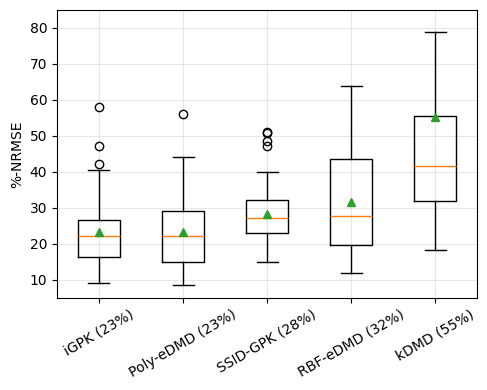

In [4]:
data, labels = [], []
for name, tensor in TestErrors.items():
    # Collapse second dimension → (19,)
    traj_mean = tensor.mean(dim=1)
    overall_mean = 100 * tensor.mean()

    data.append(100*traj_mean.detach().cpu().numpy())
    labels.append(f'{name} ({overall_mean:.0f}%)')

# Create violin plot
plt.figure(figsize=(5, 4))
plt.boxplot(data, showmeans=True, widths=0.5)

plt.xticks(range(1, len(labels) + 1), labels, rotation=30)
plt.ylabel("%-NRMSE")
# plt.title("Test Error Distribution Across Models")
plt.grid(alpha=0.3)
plt.ylim((5.,85.))

plt.tight_layout()
plt.show()
del data, labels

In [5]:
Xhat_Test = {
    "Poly-eDMD": results_sweep[1].get('test', None).get('Xhat', None),
    "RBF-eDMD":  results_sweep[2].get('test', None).get('Xhat', None),
    "kDMD":      results_kDMD[2].get('TestTraj', None),
    "SSID-GPK":  results_sweep[3].get('test', None).get('Xhat', None),
    "iGPK":      results_sweep[0].get('test', None).get('Xhat', None),
}   # each value is a tensor of shape (num_traj, num_states, num_time-steps)
Xcvhat_Test = {
    "SSID-GPK":  results_sweep[3].get('test', None).get('Xcvhat', None),
    "iGPK":      results_sweep[0].get('test', None).get('Xcvhat', None)
}   # each value is a tensor of shape (num_traj, num_states, num_states, num_time-steps)
Xhat_Test['kDMD'] = Xhat_Test['kDMD'][:, :, :100]

traj_idx = torch.argmin(TestErrors['iGPK'].mean(dim=1))
print(f'Producing plot for Test Trajectory {traj_idx}')

Producing plot for Test Trajectory 25


### NLPD for Fun

In [17]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Cart_data", 0.6, 0.4, clip=100)

SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)
SimData = gpk.add_noise(SimData_clean, noise_type="uniform",
    intensity=0.15, seed=100)

GT_test = SimData[nTrain:nTrain+nTest, :, :N-1]  # (nTest, n, N)
XhatTest, XhatTest_ssid = Xhat_Test['iGPK'], Xhat_Test['SSID-GPK']
XcvhatTest, XcvhatTest_ssid = Xcvhat_Test['iGPK'], Xcvhat_Test['SSID-GPK']

# Per-trajectory NLPD statistics (mean ± std across trajectories)
def _nlpd_one(y, mu, S, jitter=1e-8):
    """
    NLPD for a single multivariate Gaussian y~N(mu,S).
    y, mu: (n,)
    S: (n,n) covariance
    Returns scalar (float)
    """
    n = y.numel()
    S = 0.5 * (S + S.T)  # symmetrize
    S = S + jitter * torch.eye(n, dtype=S.dtype)
    try:
        L = torch.linalg.cholesky(S)
        logdet = 2.0 * torch.log(torch.diag(L)).sum()
        diff = (y - mu).view(n, 1)
        sol = torch.cholesky_solve(diff, L)
        quad = float((diff.T @ sol).item())
        return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)
    except Exception:
        # Diagonal fallback
        diag = torch.clamp(torch.diagonal(S), min=jitter)
        logdet = torch.log(diag).sum()
        quad = ((y - mu) ** 2 / diag).sum().item()
        return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)

def _nlpd_per_traj(Xhat, Xcv, GT):
    """
    Average NLPD per trajectory across time-steps.
    returns (nTraj,) tensor
    """
    nTraj, n, N = Xhat.shape
    traj_vals = torch.empty(nTraj, dtype=Xhat.dtype)
    for j in range(nTraj):
        acc = 0.0
        for k in range(N):
            acc += _nlpd_one(GT[j, :, k], Xhat[j, :, k],
                             torch.clamp(torch.abs(Xcv[j, :, :, k]), min=1e-6))
        traj_vals[j] = acc / N
    return traj_vals

nlpd_traj_test_igpk = _nlpd_per_traj(
    XhatTest[:, :, :N-1],       XcvhatTest[:, :, :, :N-1],       GT_test).detach().cpu()
# nlpd_traj_train_ssid = _nlpd_per_traj(XhatTrain_ssid[:,:,:N-1], XcvhatTrain_ssid[:,:,:,:N-1], GT_train).detach().cpu()
nlpd_traj_test_ssid = _nlpd_per_traj(
    XhatTest_ssid[:, :, :N-1],  XcvhatTest_ssid[:, :, :, :N-1],  GT_test).detach().cpu()

# Print summary
def _ms(x):
    return float(x.mean()), float(x.std(unbiased=False))
# m, s = _ms(nlpd_traj_train_igpk);  print(f"Train NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
# m, s = _ms(nlpd_traj_train_ssid);  print(f"Train NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")
m, s = _ms(nlpd_traj_test_igpk)
print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
m, s = _ms(nlpd_traj_test_ssid)
print(f"Test  NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")

Test  NLPD iGPK:     mean=5.9382, std=0.6769
Test  NLPD SSID-GPK: mean=14721.5483, std=20721.1559


### Trajectory Plot

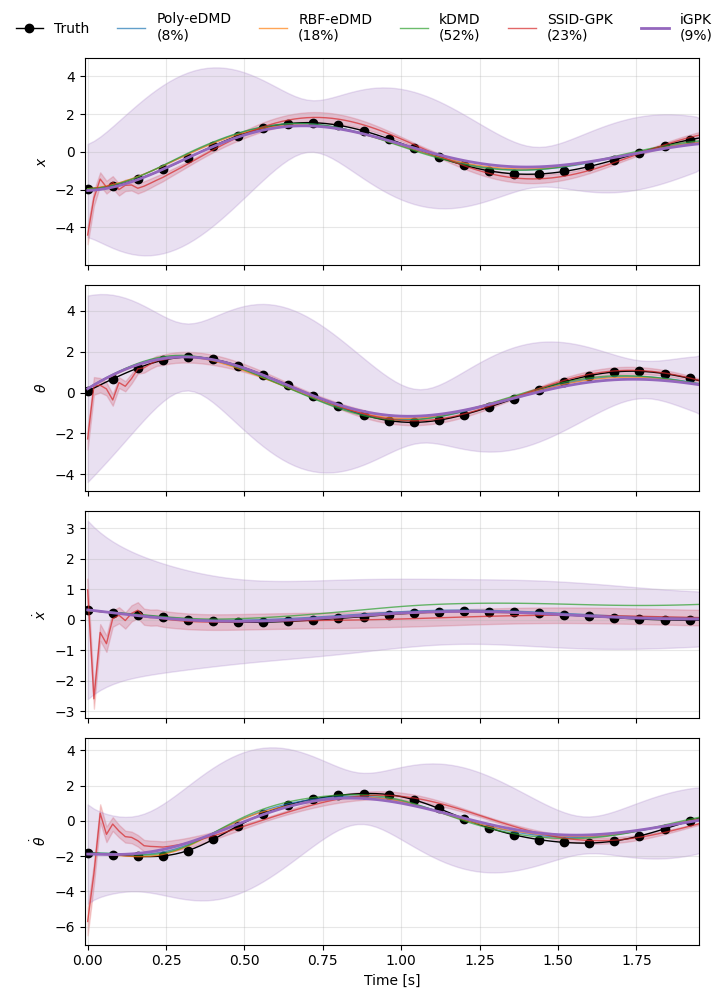

In [21]:
NRMSE_Test = {
    "Poly-eDMD": results_sweep[1].get('ErrTest', None),
    "kDMD":      results_kDMD[2].get('TestError', None),
    "RBF-eDMD":  results_sweep[2].get('ErrTest', None),
    "SSID-GPK":  results_sweep[3].get('ErrTest', None),
    "iGPK":      results_sweep[0].get('ErrTest', None),
}
# State labels (shown on y-axis for each stacked subplot)
state_labels = [r'$x$', r'$\theta$', r'$\dot{x}$', r'$\dot{\theta}$']

# Get time length from first available model
first_model = next(v for v in Xhat_Test.values() if v is not None)
T = first_model.shape[2]
t = np.arange(T) * 0.02

# Build legend label for each model using mean %-NRMSE on the chosen trajectory
legend_name_map = {}
for model_name, Xhat in Xhat_Test.items():
    if Xhat is None:
        continue

    legend_label = model_name
    if model_name in NRMSE_Test and NRMSE_Test[model_name] is not None:
        err = NRMSE_Test[model_name]

        # Assumes err shape is (num_test_trajectories, num_states)
        traj_err = err[traj_idx]
        mean_traj_err = 100 * torch.mean(traj_err)

        legend_label = f"{model_name}\n({mean_traj_err:.0f}%)"

    legend_name_map[model_name] = legend_label

fig, axes = plt.subplots(4, 1, figsize=(7, 10), sharex=True)

for i in range(4):
    axes[i].plot(
        t,
        SimData_clean[nTrain + traj_idx, i, :T],
        label='Truth',
        alpha=1,
        linewidth=1,
        color='black',
        marker='o',
        markevery=4
    )

    for model_name, Xhat in Xhat_Test.items():
        if Xhat is None:
            continue

        # (num_states, num_time_steps)
        Xtraj = Xhat[traj_idx].detach().cpu().numpy()

        if model_name == 'iGPK':
            line, = axes[i].plot(
                t, Xtraj[i],
                label=legend_name_map[model_name],
                alpha=1,
                linewidth=2
            )
        else:
            line, = axes[i].plot(
                t, Xtraj[i],
                label=legend_name_map[model_name],
                alpha=0.7,
                linewidth=1
            )
        # axes[i].set_yscale('symlog')
        axes[i].set_xlim((-0.01, 1.95))

        # Add ±1 sigma shaded band if covariance exists for this model
        if model_name in Xcvhat_Test and Xcvhat_Test[model_name] is not None:
            var_i = Xcvhat_Test[model_name][traj_idx, i, i, :].detach().cpu().numpy()
            var_i = np.maximum(var_i, 0.0)  # numerical safety
            sigma_i = np.sqrt(var_i)

            axes[i].fill_between(
                t,
                Xtraj[i] - sigma_i,
                Xtraj[i] + sigma_i,
                color=line.get_color(),
                alpha=0.2
            )

# Formatting
for i, ax in enumerate(axes):
    ax.set_ylabel(state_labels[i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')

# Collect unique legend entries only once
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='upper center',
           ncol=len(unique), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

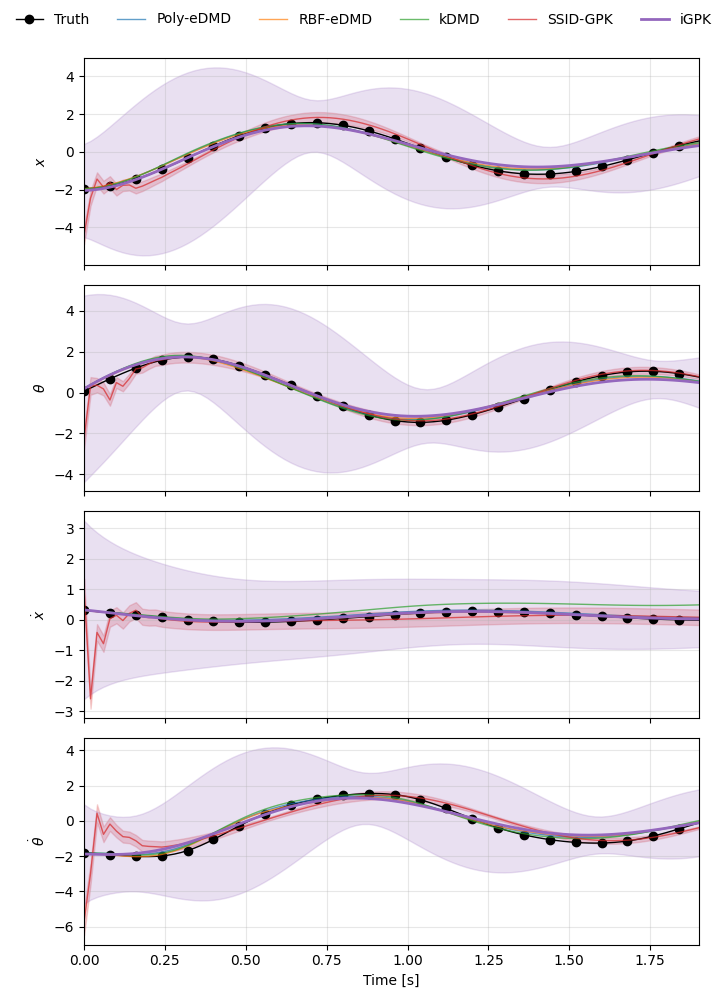

In [ ]:
# State labels (shown on y-axis for each stacked subplot)
state_labels = [r'$x$', r'$/theta$', r'$\dot{x}$', r'$\dot{\theta}$']

# Get time length from first available model
first_model = next(v for v in Xhat_Test.values() if v is not None)
T = first_model.shape[2]
t = np.arange(T)
t = t * 0.02

fig, axes = plt.subplots(4, 1, figsize=(7, 10), sharex=True)
for i in range(4):
    line, = axes[i].plot(t, SimData_clean[nTrain+traj_idx, i, :N], label='Truth', alpha=1, linewidth=1, color='black', marker='o', markevery=4)
    for model_name, Xhat in Xhat_Test.items():
        # (num_states, num_time_steps)
        Xtraj = Xhat[traj_idx].detach().cpu().numpy()

        if model_name == 'iGPK':
            line, = axes[i].plot(t, Xtraj[i], label=model_name, alpha=1, linewidth=2)
        else:
            line, = axes[i].plot(t, Xtraj[i], label=model_name, alpha=0.7, linewidth=1)
        # axes[i].set_yscale('symlog')
        axes[i].set_xlim((0, 1.9))

        # Add ±1 sigma shaded band if covariance exists for this model
        if model_name in Xcvhat_Test and Xcvhat_Test[model_name] is not None:
            # Variance of state i over time is diagonal entry [i,i,:]
            var_i = Xcvhat_Test[model_name][traj_idx, i, i, :].detach().cpu().numpy()
            var_i = np.maximum(var_i, 0.0)  # numerical safety
            sigma_i = np.sqrt(var_i)

            axes[i].fill_between(
                t,
                Xtraj[i] - sigma_i,
                Xtraj[i] + sigma_i,
                color=line.get_color(),
                alpha=0.2
            )

# Formatting
for i, ax in enumerate(axes):
    ax.set_ylabel(state_labels[i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

        for i in range(int(p/2)):
            ObsManager.add_observable(
                index=i, d=n, ns=nTrain, kernel_types=[
                    'RationalQuadratic'],
                combination='sum', noise=1e-4, m=500, device=device
            )
        for i in range(int(p/2), p):
            ObsManager.add_observable(
                index=i, d=n, ns=nTrain, kernel_types=[
                    'Gaussian', 'ExpSineSqr'],
                combination='product', noise=1e-4, m=500, device=device
            )

## Scalar NL

### Load and Reshape Data

In [21]:
nz = 5
data_n00 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.000_seed-100_20260401.pt', weights_only=True)
data_n05 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.050_seed-100_20260401.pt', weights_only=True)
data_n10 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.100_seed-100_20260401.pt', weights_only=True)
data_u05 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-uniform_int-0.050_seed-100_20260401.pt', weights_only=True)
data_u10 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-uniform_int-0.100_seed-100_20260401.pt', weights_only=True)

results_kDMD = torch.load(f'Figures/Journal/kDMD_Results/Scalar NL-{nz}D-20260401/SavedDict.pt', weights_only=True)

for i in range(4):
    name = data_n00[i].get('name', None)
    if data_n00[i].get('name', None) == 'iGPK':
        idx_iGPK = i
    elif data_n00[i].get('name', None) == 'SSID-GPK':
        idx_SSID = i
    elif data_n00[i].get('name', None) == 'Poly-eDMD':
        idx_Poly = i
    elif data_n00[i].get('name', None) == 'RBF-eDMD':
        idx_rbf = i
    else:
        print(f'ERROR: Did not find iGPK, SSID-GPK, Poly-eDMD or RBF-eDMD data records!')

TestErrors = {
    "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
    "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
    "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
    "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
    # "kDMD":      results_kDMD[2].get('TestError', None),
}
NRMSE_Test = {
    "Clean": {
        "iGPK":         data_n00[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n00[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n00[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n00[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[0].get('TestError', None),
        },
    "Uniform 5%": {
        "iGPK":         data_u05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u05[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[3].get('TestError', None),
    },
    "Uniform 10%": {
        "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[4].get('TestError', None),
    },
}

Xhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xhat', None),
    },
}

Xcvhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xcvhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
}

### Test-NRMSE Scalar NL

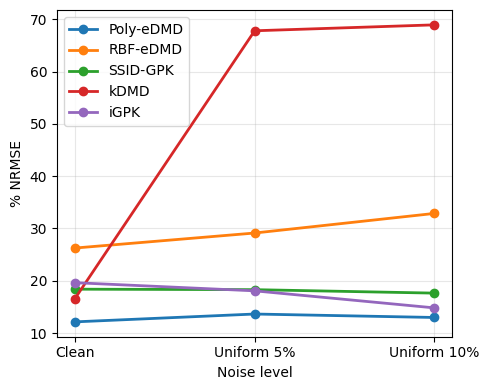

In [24]:
NRMSE_Test_bymdl = {
    "Poly-eDMD":    [100.0*float(data['Poly-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "RBF-eDMD":     [100.0*float(data['RBF-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "SSID-GPK":     [100.0*float(data['SSID-GPK'].median()) for _, data in NRMSE_Test.items()],
    "kDMD":         [100.0*float(data['kDMD'].median()) for _, data in NRMSE_Test.items()],
    "iGPK":         [100.0*float(data['iGPK'].median()) for _, data in NRMSE_Test.items()],
    }
noise_labels = NRMSE_Test.keys()
plt.figure(figsize=(5,4))
for model, mean_err in NRMSE_Test_bymdl.items():
    plt.plot([0, 5, 10], mean_err, marker="o", linewidth=2, label=model)

plt.xticks([0, 5, 10], noise_labels)
plt.xlabel("Noise level")
plt.ylabel("% NRMSE")
# plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

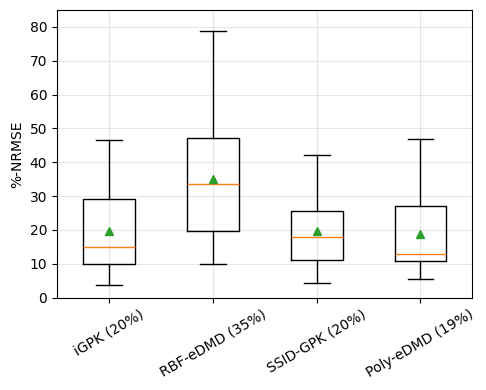

In [23]:
data, labels = [], []
for name, tensor in TestErrors.items():
    # Collapse second dimension → (19,)
    traj_mean = tensor.mean(dim=1)
    overall_mean = 100 * tensor.mean()

    data.append(100*traj_mean.detach().cpu().numpy())
    labels.append(f'{name} ({overall_mean:.0f}%)')

# Create violin plot
plt.figure(figsize=(5, 4))
plt.boxplot(data, showmeans=True, widths=0.5)

plt.xticks(range(1, len(labels) + 1), labels, rotation=30)
plt.ylabel("%-NRMSE")
# plt.title("Test Error Distribution Across Models")
plt.grid(alpha=0.3)
plt.ylim((0.,85.))

plt.tight_layout()
plt.show()
del data, labels

### NLPD - Scalar NL

Clean:
Test  NLPD iGPK:     mean=4.7458, std=11.5882
Test  NLPD SSID-GPK: mean=13.9680, std=13.5896
Uniform 5%:
Test  NLPD iGPK:     mean=2.6615, std=3.0753
Test  NLPD SSID-GPK: mean=13.5074, std=13.6830
Uniform 10%:
Test  NLPD iGPK:     mean=1.9796, std=0.5231
Test  NLPD SSID-GPK: mean=13.0841, std=13.2310


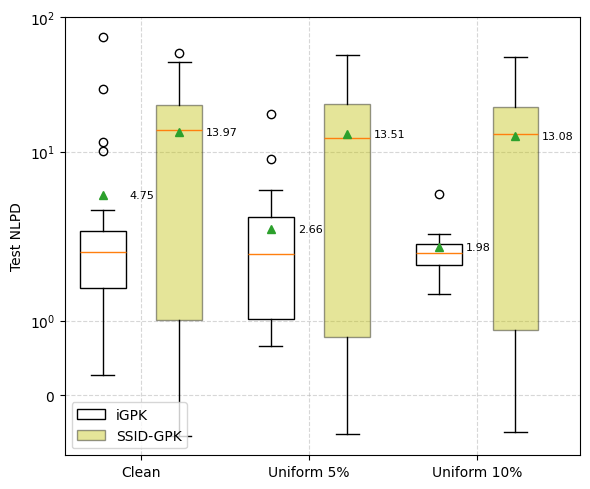

In [ ]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Scalar NL", 0.6, 0.4, clip=50)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)

intensity = -0.10
NLPD_Test = {}

for label, _ in Xhat_Test.items():
    if intensity <= 0.0:
        SimData = gpk.add_noise(SimData_clean, noise_type="gaussian",
            intensity=abs(intensity), seed=100)
    else:
        SimData = gpk.add_noise(SimData_clean, noise_type="uniform",
            intensity=intensity, seed=100)

    GT_test = SimData_clean[nTrain:nTrain+nTest+1, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = _nlpd_per_traj(
        XhatTest[:nTest, :, :N-1],       XcvhatTest[:nTest, :, :, :N-1], GT_test[:nTest, :, :]).detach().cpu()
    nlpd_traj_test_ssid = _nlpd_per_traj(
        XhatTest_ssid[:nTest, :, :N-1],  XcvhatTest_ssid[:nTest, :, :, :N-1],  GT_test[:nTest, :, :]).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

    # Print summary
    print(f'{label}:')
    m, s = _ms(nlpd_traj_test_igpk)
    print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
    m, s = _ms(nlpd_traj_test_ssid)
    print(f"Test  NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")
    intensity += 0.05

labels = list(NLPD_Test.keys())

data, positions, xticks = [], [], []

pos = 1
for label in labels:
    igpk = NLPD_Test[label]['iGPK'].numpy()
    ssid = NLPD_Test[label]['SSID-GPK'].numpy()

    # Add both models for this label
    data.extend([igpk, ssid])
    positions.extend([pos, pos + 1])

    # Center tick between the two boxes
    xticks.append(pos + 0.5)

    pos += 2.2  # spacing between groups

fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showmeans=True)

# Optional: color coding
for i, patch in enumerate(bp['boxes']):
    if i % 2 == 0:
        patch.set_facecolor('w')   # iGPK
    else:
        patch.set_facecolor('y') # SSID-GPK
        patch.set_alpha(0.4)

# X-axis formatting
ax.set_xticks(xticks)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Test NLPD")
ax.set_yscale('symlog')
ax.set_ylim((-0.8, 100))
xmin, xmax = ax.get_xlim()
ax.set_xlim((xmin, xmax*1.05))

# Legend
ax.legend([bp["boxes"][0], bp["boxes"][1]],
            ["iGPK", "SSID-GPK"],
            loc="lower left")

# --- After creating the boxplot ---
for i, (d, x) in enumerate(zip(data, positions)):
    mean_val = np.mean(d)

    ax.text(
        x+0.35, mean_val ,
        f"{mean_val:.2f}",
        ha='left', va='center',
        fontsize=8
    )

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

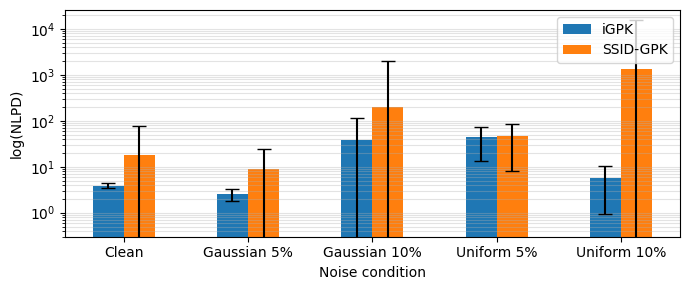

In [ ]:
# -------------------------
# Data from the LaTeX table
# -------------------------
conditions = ["Clean", "Gaussian 5%",
              "Gaussian 10%", "Uniform 5%", "Uniform 10%"]
x = np.arange(len(conditions))  # categorical axis
data = {
    "iGPK": {
        "mean": [3.89, 2.58, 37.81, 43.5, 5.65],
        "std":  [0.45, 0.74, 76.41, 29.9, 4.7],
    },
    "SSID-GPK": {
        "mean": [18.13, 8.73, 204.13, 46.64, 1373.4],
        "std":  [58.9, 15.21, 1806.5, 38.41, 14491.6],
    },
}

# -------------------------
# Plot (landscape + log y)
# -------------------------
plt.figure(figsize=(7, 3))  # landscape aspect ratio

bar_width = 0.25
offsets = [-bar_width / 2, bar_width / 2]

for (model, stats), dx in zip(data.items(), offsets):
    mean = np.array(stats["mean"], dtype=float)
    std = np.array(stats["std"], dtype=float)

    plt.bar(
        x + dx, mean, bar_width,
        yerr=std, capsize=5,
        label=model
    )

plt.xticks(x, conditions)
plt.xlabel("Noise condition")
plt.ylabel("log(NLPD)")
# plt.title("NLPD Comparison (mean ± 1 std)")
plt.yscale("log")

# Prevent pathological lower bounds in log-space
plt.ylim(bottom=0.3)

plt.grid(True, which="both", axis="y", alpha=0.35)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Inhibited Predator-Prey

In [7]:
results_sweep = torch.load(f'Figures/Journal/Inhibited Predator-Prey_10D_20260324/AllData_Inhibited_Predator-Prey_noise-gaussian_int-0.000_seed-100_20260324.pt', weights_only=True)
results_kDMD = torch.load('Figures/Journal/kDMD_Results/Cart_data-35D-20260325/SavedDict.pt', weights_only=True)
# TestErrors = {
#     "iGPK":      results_sweep[0].get('ErrTest', None),
#     "Poly-eDMD": results_sweep[1].get('ErrTest', None),
#     "SSID-GPK":  results_sweep[3].get('ErrTest', None),
#     "RBF-eDMD":  results_sweep[2].get('ErrTest', None),
#     "kDMD":      results_kDMD[2].get('TestError', None),
# }
data_n00 = torch.load(f'Figures/Journal/Inhibited Predator-Prey_10D_20260324/AllData_Inhibited_Predator-Prey_noise-gaussian_int-0.000_seed-100_20260324.pt', weights_only=True)
data_n05 = torch.load(f'Figures/Journal/Inhibited Predator-Prey_10D_20260324/AllData_Inhibited_Predator-Prey_noise-gaussian_int-0.050_seed-100_20260324.pt', weights_only=True)
data_n10 = torch.load(f'Figures/Journal/Inhibited Predator-Prey_10D_20260324/AllData_Inhibited_Predator-Prey_noise-gaussian_int-0.100_seed-100_20260324.pt', weights_only=True)


In [13]:
Xhat_Test = {
    "Clean": {
        'Poly-eDMD': data_n00[1].get('train', None).get('Xhat', None),
        'RBF-eDMD': data_n00[2].get('train', None).get('Xhat', None),
        'SSID-GPK': data_n00[3].get('train', None).get('Xhat', None),
        'iGPK': data_n00[0].get('train', None).get('Xhat', None),
    },
    "Gaussian 5%": {
        'Poly-eDMD': data_n05[1].get('train', None).get('Xhat', None),
        'RBF-eDMD': data_n05[2].get('train', None).get('Xhat', None),
        'SSID-GPK': data_n05[3].get('train', None).get('Xhat', None),
        'iGPK': data_n05[0].get('train', None).get('Xhat', None),
    },
    "Gaussian 10%": {
        'Poly-eDMD': data_n10[1].get('train', None).get('Xhat', None),
        'RBF-eDMD': data_n10[2].get('train', None).get('Xhat', None),
        'SSID-GPK': data_n10[3].get('train', None).get('Xhat', None),
        'iGPK': data_n10[0].get('train', None).get('Xhat', None),
    },
}

Xcvhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[3].get('train', None).get('Xcvhat', None),
        'iGPK': data_n00[0].get('train', None).get('Xcvhat', None),
        },
    "Gaussian 5%": {
        'SSID-GPK': data_n05[3].get('train', None).get('Xcvhat', None),
        'iGPK': data_n05[0].get('train', None).get('Xcvhat', None),
    },
    "Gaussian 10%": {
        'SSID-GPK': data_n10[3].get('train', None).get('Xcvhat', None),
        'iGPK': data_n10[0].get('train', None).get('Xcvhat', None),
    },
}

In [20]:
Xhat_Test['Clean']['iGPK'].shape

torch.Size([80, 2, 100])

### NLPD - IPP

In [25]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Inhibited Predator-Prey", 0.4, 0.6, clip=None)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)

intensity = 0.0
NLPD_Test = {}

for label, _ in Xhat_Test.items():
    SimData = gpk.add_noise(SimData_clean, noise_type="gaussian",
        intensity=intensity, seed=100)

    GT_test = SimData_clean[nTrain:nTrain+nTest, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = _nlpd_per_traj(
        XhatTest[:, :, :N-1],       XcvhatTest[:, :, :, :N-1],       GT_test).detach().cpu()
    nlpd_traj_test_ssid = _nlpd_per_traj(
        XhatTest_ssid[:, :, :N-1],  XcvhatTest_ssid[:, :, :, :N-1],  GT_test).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

    # Print summary
    print(f'{label}:')
    m, s = _ms(nlpd_traj_test_igpk)
    print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
    m, s = _ms(nlpd_traj_test_ssid)
    print(f"Test  NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")
    intensity += 0.05

Clean:
Test  NLPD iGPK:     mean=3.9808, std=0.6024
Test  NLPD SSID-GPK: mean=15629.3458, std=12003.5888
Gaussian 5%:
Test  NLPD iGPK:     mean=4.2421, std=2.7265
Test  NLPD SSID-GPK: mean=269.3768, std=1565.5052
Gaussian 10%:
Test  NLPD iGPK:     mean=3.7660, std=2.1023
Test  NLPD SSID-GPK: mean=112.1387, std=188.2834


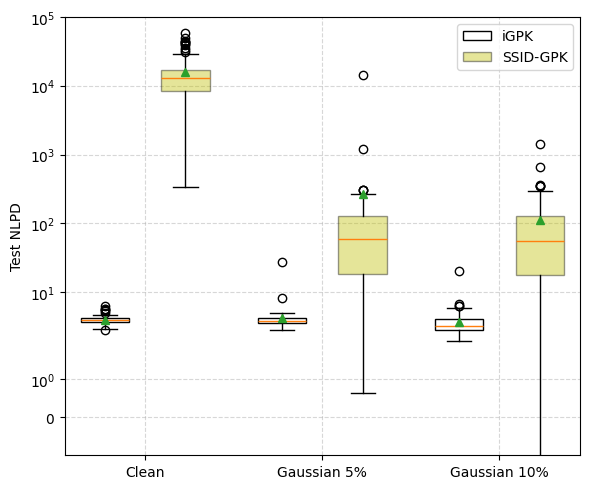

In [26]:
labels = list(NLPD_Test.keys())

data, positions, xticks = [], [], []

pos = 1
for label in labels:
    igpk = NLPD_Test[label]['iGPK'].numpy()
    ssid = NLPD_Test[label]['SSID-GPK'].numpy()

    # Add both models for this label
    data.extend([igpk, ssid])
    positions.extend([pos, pos + 1])

    # Center tick between the two boxes
    xticks.append(pos + 0.5)

    pos += 2.2  # spacing between groups

fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showmeans=True)

# Optional: color coding
for i, patch in enumerate(bp['boxes']):
    if i % 2 == 0:
        patch.set_facecolor('w')   # iGPK
    else:
        patch.set_facecolor('y') # SSID-GPK
        patch.set_alpha(0.4)

# X-axis formatting
ax.set_xticks(xticks)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Test NLPD")
ax.set_yscale('symlog')
ax.set_ylim((-1, 1e5))

# Legend
ax.legend([bp["boxes"][0], bp["boxes"][1]],
            ["iGPK", "SSID-GPK"],
            loc="upper right")

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Random Testing Sandbox

In [1]:
import torch
import matplotlib.pyplot as plt
import GPKoopman as gpk
from TrajDataGen_refactored import generate_dataset

# -----------------------------
# Load previously saved dataset
# Must use gpk.load_SimData as requested
# -----------------------------
SimData_old, ts_old, num_traj_old, N_old, _, _ = gpk.load_SimData(
    "Inhibited Predator-Prey",
    trainFrac=0.0,
    testFrac=0.0,
)

# -----------------------------
# Generate new dataset in memory
# No file save, no CLI-style output
# -----------------------------
np.random.seed(1234)
torch.manual_seed(1234)
new_data = generate_dataset(
    "inhibited_predator_prey",
    save=False,
    verbose=False,
    seed=1234
)

SimData_new = new_data["trajectories"]
ts_new = new_data["sample_time"]
num_traj_new = new_data["num_trajectories"]
N_new = new_data["num_steps"]

print("Old dataset:")
print(f"  shape            : {tuple(SimData_old.shape)}")
print(f"  sample_time      : {ts_old}")
print(f"  num_trajectories : {num_traj_old}")
print(f"  num_steps        : {N_old}")

print("\nNew dataset:")
print(f"  shape            : {tuple(SimData_new.shape)}")
print(f"  sample_time      : {ts_new}")
print(f"  num_trajectories : {num_traj_new}")
print(f"  num_steps        : {N_new}")

same_shape = SimData_old.shape == SimData_new.shape
same_ts = float(ts_old) == float(ts_new)

print("\nBasic compatibility check:")
print(f"  same_shape       : {same_shape}")
print(f"  same_sample_time : {same_ts}")

if same_shape:
    diff = SimData_new - SimData_old
    print(f"  mean abs diff    : {diff.abs().mean().item():.6e}")
    print(f"  max abs diff     : {diff.abs().max().item():.6e}")
else:
    print("  mean/max diff skipped because shapes do not match.")

# Use common limits in case anything differs slightly
num_traj = min(SimData_old.shape[0], SimData_new.shape[0])
T = min(SimData_old.shape[2], SimData_new.shape[2])

SimData_old = SimData_old[:num_traj, :, :T]
SimData_new = SimData_new[:num_traj, :, :T]

# Python uses 0-based indexing:
# 3rd trajectory -> index 2
# 14th trajectory -> index 13
traj_indices = [2, 13]
traj_labels = ["3rd trajectory", "14th trajectory"]


# -----------------------------
# Figure 1: all trajectories
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for j in range(num_traj):
    axes[0].plot(
        SimData_old[j, 0, :].cpu(),
        SimData_old[j, 1, :].cpu(),
        linewidth=0.8,
        alpha=0.7,
    )
    axes[1].plot(
        SimData_new[j, 0, :].cpu(),
        SimData_new[j, 1, :].cpu(),
        linewidth=0.8,
        alpha=0.7,
    )

axes[0].set_title("Previously saved data")
axes[1].set_title("Generated from TrajDataGen_refactored.py")

for ax in axes:
    ax.set_xlabel("State 1")
    ax.set_ylabel("State 2")
    ax.grid(True, alpha=0.3)

fig.suptitle("Inhibited Predator-Prey: all trajectories (2D phase plot)")
fig.tight_layout()
plt.show()


# -----------------------------
# Figure 2 and 3: trajectory 3 and 14
# -----------------------------
for idx, label in zip(traj_indices, traj_labels):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(
        SimData_old[idx, 0, :].cpu(),
        SimData_old[idx, 1, :].cpu(),
        label="Previously saved",
        linewidth=2.0,
    )
    ax.plot(
        SimData_new[idx, 0, :].cpu(),
        SimData_new[idx, 1, :].cpu(),
        label="Refactored generator",
        linewidth=2.0,
        linestyle="--",
    )

    ax.scatter(
        SimData_old[idx, 0, 0].cpu(),
        SimData_old[idx, 1, 0].cpu(),
        s=35,
        marker="o",
        label="Saved IC",
    )
    ax.scatter(
        SimData_new[idx, 0, 0].cpu(),
        SimData_new[idx, 1, 0].cpu(),
        s=35,
        marker="x",
        label="Generated IC",
    )

    ax.set_title(f"Inhibited Predator-Prey: {label}")
    ax.set_xlabel("State 1")
    ax.set_ylabel("State 2")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

NameError: name 'np' is not defined